# 03. Does the mismatch bite harder where births require marriage?

Part three of the Korea project. The OECD notebook found a weak negative relationship
between the gender equity mismatch and fertility, at about 0.25, with roughly half of
it coming from Korea alone and several high mismatch countries such as Portugal,
Ireland and New Zealand sitting at ordinary levels of fertility.

The idea we test here is that the mismatch can only reduce fertility through the
decisions it affects. In Korea, Japan and Türkiye almost every birth happens inside
marriage, so an unequal home is a reason not to marry, and not marrying means not
having children. In France or Sweden a couple can have children without marrying, so
the same unequal home may cost fewer births. If that is right, the mismatch should
hurt fertility more where the share of births outside marriage is low.

We add two things to the OECD dataset. The first is the share of births outside
marriage from the OECD Family Database, as a variable in its own right. The second is
an interaction between the mismatch and that share, which is the actual test. A small
regression follows, run with and without Korea.

We considered the sex ratio at birth and set it aside, since every country in today's
OECD sits in a band from 104 to 107 and there is no variation across countries to
work with. Korea's skew in the late 1980s and early 1990s, at around 115 in 1990, is
a marriage market story specific to Korea and belongs in the discussion rather than
in the data.

**Inputs**: `data/processed/oecd_mismatch.csv` (written by `02_oecd_mismatch.ipynb`)
and `data/raw/oecd_births_outside_marriage.csv` (written by `00_pull_data.ipynb`).

**Outputs**: `data/processed/oecd_mismatch_marriage.csv` (the 30-country analysis
table with the marriage variable, predictions and residuals), figures
`output/fig03_*.png`, and `output/table_regressions.csv` (Table 4 in the paper).

| Sphere | Measure | Source |
|---|---|---|
| Outcome | Total fertility rate, latest | World Bank |
| Public | Ratio of female to male labour force participation | World Bank / ILO |
| Public | Tertiary enrolment gender parity index | World Bank / UNESCO |
| Private | Men's share of unpaid work | OECD Time Use Database |
| New | Share of births outside marriage, latest | OECD Family Database |
| Control | GDP per capita at PPP | World Bank |

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from utils import (
    DATA_RAW, DATA_PROCESSED, KOREA_CODE,
    report_merge, save_figure, save_table, bar_chart, scatter_with_labels,
)

pd.set_option("display.width", 130)

## 1. Load the mismatch dataset and add the share of births outside marriage

We join the mismatch table from notebook 02 (inner, on ISO3 code) with the latest
share of births outside marriage from the OECD Family Database. Most values are from
2023; Ireland is 2019 and Belgium 2018. All 30 countries have a value, so nothing is
dropped.

The OECD notes one wrinkle in the definition. For Australia, Japan, Korea and New
Zealand the figure counts births where the parents are not registered as married to
each other, while for the other countries it counts births to mothers whose legal
status is something other than married. That is close enough for a comparison across
countries.

In [2]:
mismatch = pd.read_csv(DATA_PROCESSED / "oecd_mismatch.csv")
nonmarital = pd.read_csv(DATA_RAW / "oecd_births_outside_marriage.csv")

data = mismatch.merge(nonmarital, on="code", how="inner")
report_merge(mismatch, nonmarital, data, "mismatch + births outside marriage (inner)", "code")
data = data.sort_values("mismatch", ascending=False).reset_index(drop=True)

print("Year of the marriage value:")
print(data["nonmarital_year"].value_counts().sort_index().to_string())
data[["country", "tfr", "mismatch", "men_share_unpaid_pct", "nonmarital_pct", "nonmarital_year"]].round(1)

[mismatch + births outside marriage (inner)] left: 30 rows, right: 38 rows, merged on 'code': 30 rows
Year of the marriage value:
nonmarital_year
2018     1
2019     1
2021     1
2023    22
2024     5


,country,tfr,mismatch,men_share_unpaid_pct,nonmarital_pct,nonmarital_year
0,Portugal,1.4,57.5,22.7,59.5,2023
1,Japan,1.2,50.7,18.4,2.4,2023
2,Korea,0.7,46.8,18.6,4.7,2024
3,New Zealand,1.6,43.7,34.8,48.4,2024
4,Türkiye,1.5,43.0,18.1,3.1,2023
5,Ireland,1.5,41.3,30.3,38.4,2019
6,Latvia,1.2,39.8,33.9,37.3,2023
7,Italy,1.2,39.7,29.9,40.5,2023
8,Lithuania,1.1,39.1,34.2,27.3,2023
9,Australia,1.5,38.6,35.6,39.9,2023


## 2. The new variable on its own

On the left is the share of births outside marriage across the OECD with Korea
highlighted, and on the right that share plotted against fertility.

Korea at 4.7 percent, Japan at 2.4, Türkiye at 3.1 and Greece at 9.7 are the only
countries under 10 percent. The OECD median is about 40 percent, and the Nordic
countries, France, Portugal and the Latin American members all sit above 50. The
scatter shows a clear positive relationship of about 0.57, so countries where
childbearing has come apart from marriage tend to have higher fertility. That is
already stronger than anything the mismatch produced, and it is not simply Mexico or
Korea pulling the line, since dropping both still leaves a correlation of about
0.36.

Saved figure: output/fig03_births_outside_marriage.png


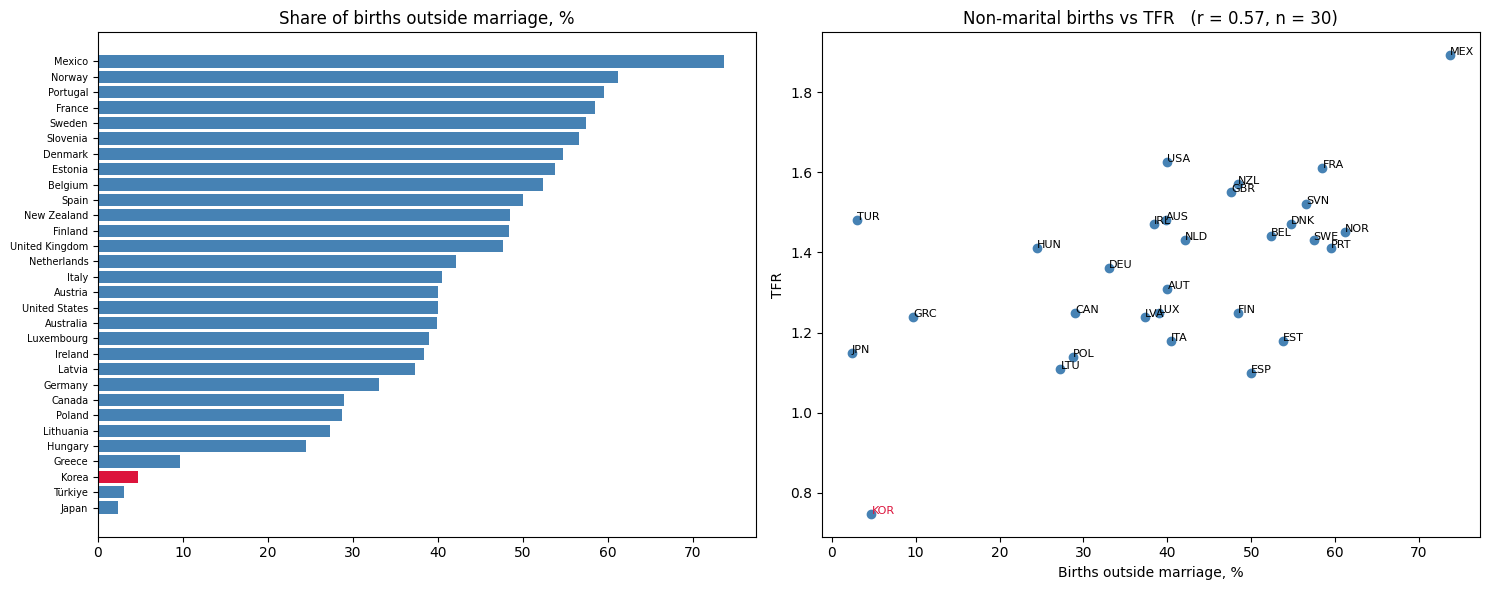

r, non-marital share vs TFR, all:                  0.573
r, non-marital share vs TFR, without Mexico+Korea: 0.358
r, non-marital share vs mismatch:                  -0.334

Mean TFR where births outside marriage < 10% (n = 4): 1.15
Mean TFR elsewhere (n = 26): 1.39


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bar_chart(axes[0], data, "nonmarital_pct", "Share of births outside marriage, %")
scatter_with_labels(axes[1], data, "nonmarital_pct", "tfr", "Births outside marriage, %",
                    "Non-marital births vs TFR", show_n=True)
plt.tight_layout()
save_figure(fig, "fig03_births_outside_marriage")
plt.show()

without_two = data[~data["code"].isin(["MEX", KOREA_CODE])]
print("r, non-marital share vs TFR, all:                 ", round(data["tfr"].corr(data["nonmarital_pct"]), 3))
print("r, non-marital share vs TFR, without Mexico+Korea:", round(without_two["tfr"].corr(without_two["nonmarital_pct"]), 3))
print("r, non-marital share vs mismatch:                 ", round(data["mismatch"].corr(data["nonmarital_pct"]), 3))

strict = data["nonmarital_pct"] < 10
print()
print(f"Mean TFR where births outside marriage < 10% (n = {strict.sum()}): {data.loc[strict, 'tfr'].mean():.2f}")
print(f"Mean TFR elsewhere (n = {(~strict).sum()}): {data.loc[~strict, 'tfr'].mean():.2f}")

## 3. Split sample check

The simplest version of the interaction test is to split countries at the median
share of births outside marriage and see whether the relationship between mismatch
and fertility is stronger in the half where births are tied to marriage.

At first glance it is, with a correlation of about 0.38 in the low half against about
0.05 in the high half. The low half contains Korea, though, and dropping it takes the
correlation to about 0.18, so again the pattern is mostly one country.

In [4]:
median_nm = data["nonmarital_pct"].median()
low_group = data[data["nonmarital_pct"] <= median_nm]
high_group = data[data["nonmarital_pct"] > median_nm]
low_no_korea = low_group[low_group["code"] != KOREA_CODE]

print("Median non-marital share:", round(median_nm, 1))
print()
print(f"Low non-marital half  (n = {len(low_group)}):  r mismatch vs TFR = {low_group['tfr'].corr(low_group['mismatch']):.3f}")
print(f"  ...same half without Korea (n = {len(low_no_korea)}): {low_no_korea['tfr'].corr(low_no_korea['mismatch']):.3f}")
print(f"High non-marital half (n = {len(high_group)}):  r mismatch vs TFR = {high_group['tfr'].corr(high_group['mismatch']):.3f}")
print()
print("Low half: ", ", ".join(sorted(low_group["country"])))
print("High half:", ", ".join(sorted(high_group["country"])))

Median non-marital share: 40.2

Low non-marital half  (n = 15):  r mismatch vs TFR = -0.381
  ...same half without Korea (n = 14): -0.186
High non-marital half (n = 15):  r mismatch vs TFR = -0.050

Low half:  Australia, Austria, Canada, Germany, Greece, Hungary, Ireland, Japan, Korea, Latvia, Lithuania, Luxembourg, Poland, Türkiye, United States
High half: Belgium, Denmark, Estonia, Finland, France, Italy, Mexico, Netherlands, New Zealand, Norway, Portugal, Slovenia, Spain, Sweden, United Kingdom


## 4. Regression

Four models, each adding one term:

1. Fertility on the mismatch
2. Fertility on the mismatch and the share of births outside marriage
3. Model 2 plus the interaction between the two
4. Model 3 plus log GDP per capita

We centre the mismatch and the share of births outside marriage on their means before
forming the product, so the mismatch coefficient reads as its effect at an average
share, and the interaction reads as how that effect changes with each percentage
point of births outside marriage. The prediction from the introduction is a positive
interaction, meaning the mismatch should hurt less as births come apart from
marriage.

In [5]:
for column in ["mismatch", "nonmarital_pct", "log_gdp"]:
    data[column + "_c"] = data[column] - data[column].mean()

formulas = {
    "(1)": "tfr ~ mismatch_c",
    "(2)": "tfr ~ mismatch_c + nonmarital_pct_c",
    "(3)": "tfr ~ mismatch_c + nonmarital_pct_c + mismatch_c:nonmarital_pct_c",
    "(4)": "tfr ~ mismatch_c + nonmarital_pct_c + mismatch_c:nonmarital_pct_c + log_gdp_c",
}


def coefficient_table(model):
    """Coefficients with 95% confidence intervals and p-values, one row per term."""
    intervals = model.conf_int()
    return pd.DataFrame({"coef": model.params, "ci_low": intervals[0],
                         "ci_high": intervals[1], "p": model.pvalues}).round(4)


def run_models(frame, label):
    """Fit every formula on `frame`, print each, return {model number: fitted model}."""
    print("========", label, "( n =", len(frame), ")")
    fitted = {}
    for number, formula in formulas.items():
        model = smf.ols(formula, data=frame).fit()
        fitted[number] = model
        print()
        print(number, formula, "   adj. R² =", round(model.rsquared_adj, 3))
        display(coefficient_table(model))
    return fitted


models_all = run_models(data, "All countries")

======== All countries ( n = 30 )

(1) tfr ~ mismatch_c    adj. R² = 0.03


,coef,ci_low,ci_high,p
Intercept,1.3583,1.2793,1.4373,0.00
mismatch_c,-0.0059,-0.0148,0.0029,0.18



(2) tfr ~ mismatch_c + nonmarital_pct_c    adj. R² = 0.283


,coef,ci_low,ci_high,p
Intercept,1.3583,1.2903,1.4263,0.0000
mismatch_c,-0.0016,-0.0097,0.0065,0.6892
nonmarital_pct_c,0.0066,0.0025,0.0106,0.0027



(3) tfr ~ mismatch_c + nonmarital_pct_c + mismatch_c:nonmarital_pct_c    adj. R² = 0.256


,coef,ci_low,ci_high,p
Intercept,1.3571,1.2840,1.4301,0.0000
mismatch_c,-0.0016,-0.0098,0.0067,0.7033
nonmarital_pct_c,0.0067,0.0020,0.0114,0.0072
mismatch_c:nonmarital_pct_c,-0.0000,-0.0005,0.0004,0.9136



(4) tfr ~ mismatch_c + nonmarital_pct_c + mismatch_c:nonmarital_pct_c + log_gdp_c    adj. R² = 0.244


,coef,ci_low,ci_high,p
Intercept,1.3574,1.2836,1.4312,0.0000
mismatch_c,-0.0022,-0.0108,0.0063,0.5946
nonmarital_pct_c,0.0067,0.0019,0.0114,0.0081
mismatch_c:nonmarital_pct_c,-0.0000,-0.0005,0.0004,0.9362
log_gdp_c,-0.0773,-0.2851,0.1305,0.4508


What happens:

- Model 1 reproduces the OECD notebook. The mismatch alone has a small negative
  coefficient of about 0.006 births per point of mismatch, a confidence interval that
  straddles zero, and an adjusted R² of about 0.03.
- Model 2 is the important one. Adding the share of births outside marriage lifts
  adjusted R² to about 0.28, and its coefficient is clearly positive at about 0.0066
  per percentage point with a p value of about 0.003, which works out to roughly 0.33
  births between a country at 5 percent and one at 55 percent. The mismatch
  coefficient falls to about 0.0015 in the negative direction with a p value near
  0.7. The two variables are themselves correlated at about 0.34, and once both are
  in the model the share of births outside marriage carries the relationship.
- Model 3 shows an interaction that is essentially zero, with a coefficient near
  0.0000 and a p value of about 0.9. This does not look like an effect that is
  present but noisy, since the point estimate itself is nil. The moderation story
  does not show up.
- Model 4 shows that income adds nothing, as in the OECD notebook.

## 5. Without Korea, and who is doing the work

The same four models on the 29 countries other than Korea, followed by Cook's
distance from Model 3 to see which countries move the fit most.

In [6]:
data_no_korea = data[data["code"] != KOREA_CODE].reset_index(drop=True)
models_no_korea = run_models(data_no_korea, "Without Korea")

======== Without Korea ( n = 29 )

(1) tfr ~ mismatch_c    adj. R² = -0.019


,coef,ci_low,ci_high,p
Intercept,1.3781,1.3072,1.4490,0.0000
mismatch_c,-0.0027,-0.0108,0.0054,0.4927



(2) tfr ~ mismatch_c + nonmarital_pct_c    adj. R² = 0.169


,coef,ci_low,ci_high,p
Intercept,1.3730,1.3087,1.4373,0.0000
mismatch_c,-0.0002,-0.0078,0.0074,0.9659
nonmarital_pct_c,0.0051,0.0012,0.0091,0.0131



(3) tfr ~ mismatch_c + nonmarital_pct_c + mismatch_c:nonmarital_pct_c    adj. R² = 0.162


,coef,ci_low,ci_high,p
Intercept,1.3654,1.2983,1.4325,0.0000
mismatch_c,0.0003,-0.0074,0.0080,0.9323
nonmarital_pct_c,0.0059,0.0015,0.0102,0.0100
mismatch_c:nonmarital_pct_c,-0.0002,-0.0006,0.0002,0.3865



(4) tfr ~ mismatch_c + nonmarital_pct_c + mismatch_c:nonmarital_pct_c + log_gdp_c    adj. R² = 0.141


,coef,ci_low,ci_high,p
Intercept,1.3655,1.2974,1.4335,0.0000
mismatch_c,-0.0002,-0.0083,0.0078,0.9526
nonmarital_pct_c,0.0059,0.0015,0.0103,0.0112
mismatch_c:nonmarital_pct_c,-0.0002,-0.0006,0.0003,0.4144
log_gdp_c,-0.0575,-0.2488,0.1338,0.5411


In [7]:
model_3 = models_all["(3)"]
cooks = pd.Series(model_3.get_influence().cooks_distance[0], index=data["country"])
print("Cook's distance, Model 3 (larger = more influence on the fit):")
print(cooks.sort_values(ascending=False).head(6).round(3).to_string())

Cook's distance, Model 3 (larger = more influence on the fit):
country
Korea      0.471
Türkiye    0.316
Mexico     0.286
Spain      0.045
Finland    0.043
Estonia    0.036


Without Korea the coefficient on births outside marriage shrinks a little, to about
0.005 with a p value near 0.01, but it keeps its sign and its significance, while the
mismatch coefficient is now indistinguishable from zero. Korea, Türkiye and Mexico
are the three influential points. Türkiye and Mexico matter because they combine
unusual shares of births outside marriage, at 3 and 74 percent, with the two highest
fertility rates. Korea matters because it sits 0.36 births below even where Model 3
puts it.

In [8]:
# Table 4 in the paper: all six columns in one tidy table.
term_labels = {
    "mismatch_c": "Mismatch",
    "nonmarital_pct_c": "Births outside marriage",
    "mismatch_c:nonmarital_pct_c": "Mismatch x marriage",
    "log_gdp_c": "log GDP per capita",
    "Intercept": "Intercept",
}
columns = {("All countries", k): m for k, m in models_all.items()}
columns.update({("Without Korea", k): m for k, m in models_no_korea.items() if k in ("(2)", "(3)")})

rows = []
for (sample, number), model in columns.items():
    intervals = model.conf_int()
    for term in model.params.index:
        rows.append({"sample": sample, "model": number, "term": term_labels[term],
                     "coef": model.params[term], "ci_low": intervals.loc[term, 0],
                     "ci_high": intervals.loc[term, 1], "p": model.pvalues[term],
                     "adj_r2": model.rsquared_adj, "n": int(model.nobs)})
regression_table = pd.DataFrame(rows).round(4)
save_table(regression_table, "table_regressions")
regression_table.pivot(index="term", columns=["sample", "model"], values="coef").loc[list(term_labels.values())]

Saved table: output/table_regressions.csv


sample                  All countries                         Without Korea        
model                             (1)     (2)     (3)     (4)           (2)     (3)
term                                                                               
Mismatch                      -0.0059 -0.0016 -0.0016 -0.0022       -0.0002  0.0003
Births outside marriage           NaN  0.0066  0.0067  0.0067        0.0051  0.0059
Mismatch x marriage               NaN     NaN -0.0000 -0.0000           NaN -0.0002
log GDP per capita                NaN     NaN     NaN -0.0773           NaN     NaN
Intercept                      1.3583  1.3583  1.3571  1.3574        1.3730  1.3654

## 6. Actual and predicted fertility

The prediction from Model 3 for each country, plotted against its actual fertility.
Countries below the line have lower fertility than the mismatch and the share of
births outside marriage would together suggest.

Saved figure: output/fig03_actual_vs_predicted.png


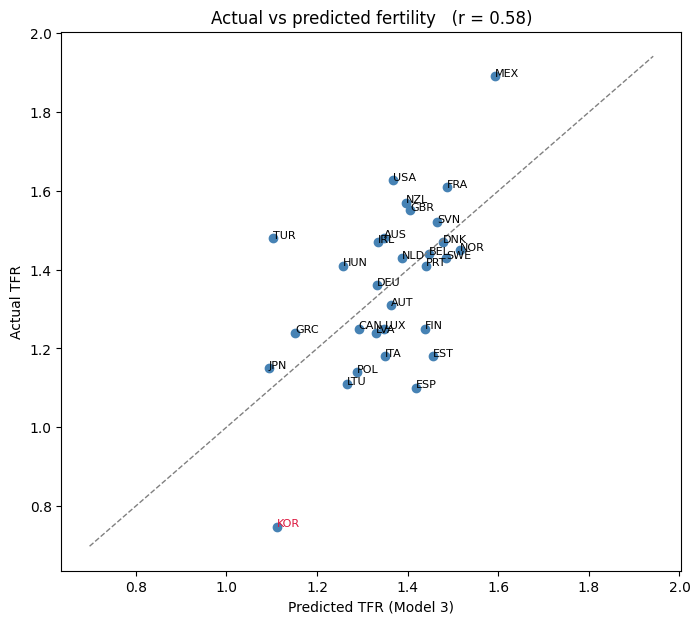

Saved table: data/processed/oecd_mismatch_marriage.csv
Largest negative residuals (actual well below predicted):
  country  tfr  predicted_tfr  residual
    Korea 0.75           1.11     -0.36
    Spain 1.10           1.42     -0.32
  Estonia 1.18           1.45     -0.27
  Finland 1.25           1.44     -0.19
    Italy 1.18           1.35     -0.17
Lithuania 1.11           1.27     -0.16


In [9]:
data["predicted_tfr"] = model_3.fittedvalues
data["residual"] = model_3.resid

fig, ax = plt.subplots(figsize=(8, 7))
scatter_with_labels(ax, data, "predicted_tfr", "tfr", "Predicted TFR (Model 3)", "Actual vs predicted fertility")
ax.set_ylabel("Actual TFR")
low = min(data["predicted_tfr"].min(), data["tfr"].min()) - 0.05
high = max(data["predicted_tfr"].max(), data["tfr"].max()) + 0.05
ax.plot([low, high], [low, high], color="grey", linestyle="--", linewidth=1)
save_figure(fig, "fig03_actual_vs_predicted")
plt.show()

save_table(data, "oecd_mismatch_marriage", folder=DATA_PROCESSED)

print("Largest negative residuals (actual well below predicted):")
print(data[["country", "tfr", "predicted_tfr", "residual"]].sort_values("residual").head(6).round(2).to_string(index=False))

Korea is predicted at about 1.11 and sits at 0.75. Spain at 0.32 below, Estonia at
0.28 below and Finland at 0.19 below are the next largest misses, and none of them
has a low share of births outside marriage, so the unexplained cases of low fertility
are not all countries where births are tied to marriage.

## 7. Takeaways

- The marriage channel matters, but as a main effect rather than as a moderator. The
  share of births outside marriage is the strongest single predictor of fertility in
  this dataset, with a correlation of about 0.57 and an adjusted R² that rises from
  0.03 to 0.28. It holds without Korea and Mexico, and it is not an income effect.
  The interaction with the mismatch is zero, so the mismatch does not appear to hurt
  more where births require marriage. The share of births outside marriage simply
  predicts fertility on its own.
- The mismatch does not survive. Once the share of births outside marriage is in the
  model, the mismatch coefficient is about 0.0015 in the negative direction with
  Korea included and about zero without it. The weak correlation across the OECD in
  the previous notebook was in part the mismatch standing in for how tightly
  childbearing is tied to marriage.
- What the share of births outside marriage measures is still an open question. It is
  not obviously a cause. A high share means marriage is optional for forming a
  family, but it also tracks a broader loosening of family norms, covering
  cohabitation, later marriage or none at all, and acceptance of single parenthood,
  which the demographic literature links to a recovery in fertility in the Nordic and
  French cases. For the report it is safer to describe it as marking how tightly
  birth and marriage are linked as institutions, and to note that the countries where
  that link is strict, namely Korea, Japan, Türkiye and Greece, average about 1.15
  births against 1.39 elsewhere.
- Korea remains the outlier, 0.36 births below what the mismatch and the share of
  births outside marriage together predict. A strict link between birth and marriage
  explains why Korea is in the low fertility group, but it does not explain why Korea
  sits 0.4 below Japan, which has the same link and a higher mismatch score. The
  remaining gap is where the factors specific to Korea have to do the work, including
  the collapse in marriage itself, working hours, housing and the cost of private
  education.
- Limits. 30 countries, measured at one point in time, with time use data of varying
  age and a measure of births outside marriage whose definition differs slightly for
  Korea, Japan, Australia and New Zealand. Three influential points: Korea, Türkiye
  and Mexico.
